# Schadner implied volatility: from the naive version to C++

This notebook summarizes the whole effort in one place, from the original bisection baseline through Schadner's explicit formula to the compiled solver. All numbers are recomputed when it runs, on the same 17,966 paired SPX options from the four quarterly files.

There are two scopes, and the notebook keeps them apart.

- **Full price-to-IV** is the whole path from a quoted option price to an implied volatility. It was measured for the bisection baseline, the naive Schadner function called once per row, the vectorized Schadner, the Python table-plus-Halley solver, and the same pipeline with the quantile computed in C++.
- **Quantile step only** is the single inverse-Gaussian quantile that the formula needs. The C++ port covers only this step. The price mapping, the no-arbitrage mask and the at-the-forward case are still Python. So the full price-to-IV run with C++ is a hybrid. Python does everything except the quantile, and C++ computes the quantile through a shared library called with `ctypes`.

Stages

1. Bisection baseline, one row at a time.
2. Naive Schadner, one row at a time, with `scipy.stats.invgauss.ppf` for the quantile.
3. Vectorized Schadner, the same formula on whole arrays.
4. Table seed plus one Halley step, in Python.
5. The same solver with the quantile computed in C++ and called from Python.

Sections

1. Full price-to-IV, stages 1 to 4
2. The quantile step, stages 3 to 5
3. All stages in one table and one chart
4. What changed at each step
5. Accuracy
6. Caveats and what is not done

Detail on the solver lives in `quantile_solver/quantile_solver_summary.ipynb`. The first-pass notebooks are `iv_inversion_schadner_explicit.ipynb` and `hand_rolled_seed_halley.ipynb`.


In [1]:
import json
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.stats import invgauss, norm

warnings.simplefilter("ignore")
sys.path.insert(0, str(Path("quantile_solver").resolve()))
import ig_quantile as q
import ig_quantile_cpp


def show(df, formats=None, index=True):
    """Render a DataFrame as an HTML table with per-column number formats."""
    out = df.copy()
    for col, fmt in (formats or {}).items():
        out[col] = out[col].map(lambda v, f=fmt: f.format(v) if pd.notna(v) else "n/a")
    display(HTML(out.to_html(index=index, escape=True, border=0)))


SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "regular", "axes.titlelocation": "left",
    "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})

# Reuse the first-pass notebook's own definitions instead of copying them, so the baseline
# and the naive Schadner here are exactly the code in iv_inversion_schadner_explicit.ipynb.
def run_notebook_cells(path, indices):
    nb = json.loads(Path(path).read_text())
    for i in indices:
        exec("".join(nb["cells"][i]["source"]), globals())

run_notebook_cells("iv_inversion_schadner_explicit.ipynb", [5, 7, 9])
for name in ("implied_volatility_bisection", "implied_volatility_schadner", "implied_volatility_schadner_vectorized"):
    assert callable(globals()[name]), name

DATA_DIR = Path("..").resolve() / "fim500project" / "SPXIV-Surface" / "data"
price, spot, strike, t, rate, dividend = q._load_real_inputs(DATA_DIR)
rows = pd.DataFrame({"price": price, "spot": spot, "strike": strike, "t": t})
N = len(rows)
print(f"{N:,} paired options, risk-free rate {rate:.0%}, dividend yield {dividend:.0%}")


17,966 paired options, risk-free rate 5%, dividend yield 0%


## 1. Full price-to-IV, stages 1 to 4

Stages 1 and 2 loop over rows with `DataFrame.apply`, as the original notebook does. Stage 3 is one call on arrays. Stage 4 adds the no-arbitrage mask, so that all four stages return NaN for the same quotes. The bisection stage takes about 13 seconds, so this cell is the slow one.


In [2]:
def args(row):
    return dict(target_price=row["price"], spot=row["spot"], strike=row["strike"],
                time_to_expiry=row["t"], rate=rate, dividend=dividend)


def timed(fn):
    start = time.perf_counter()
    out = fn()
    return time.perf_counter() - start, out


def best_of(fn, repeats=15):
    results = [timed(fn) for _ in range(repeats)]
    return min(r[0] for r in results), results[-1][1]


sec_bisect, iv_bisect = timed(lambda: rows.apply(lambda r: implied_volatility_bisection(**args(r)), axis=1).to_numpy())
sec_naive, iv_naive = timed(lambda: rows.apply(lambda r: implied_volatility_schadner(**args(r)), axis=1).to_numpy())
sec_vec, iv_vec = best_of(lambda: implied_volatility_schadner_vectorized(
    rows["price"], rows["spot"], rows["strike"], rows["t"], rate, dividend))


def iv_pipeline(quantile=None):
    """Table seed plus one Halley step, with the same no-arbitrage mask the vectorized version applies.

    quantile swaps the (s, mu) -> x function, so the same pipeline runs with the Python or the C++ quantile.
    """
    p_, s_, k_, t_ = (rows[c].to_numpy() for c in ("price", "spot", "strike", "t"))
    lower = np.maximum(s_ * np.exp(-dividend * t_) - k_ * np.exp(-rate * t_), 0.0)
    ok = (t_ > 0) & (p_ >= lower - 1e-6) & (p_ <= s_ * np.exp(-dividend * t_) + 1e-6)
    sigma = q.implied_vol_from_quantile(p_, s_, k_, t_, rate, dividend, quantile=quantile)
    return np.where(ok & np.isfinite(sigma) & (sigma > 0), sigma, np.nan)


sec_table, iv_table = best_of(iv_pipeline)

cpp_available = True
try:
    ig_quantile_cpp.build()
    sec_hybrid, iv_hybrid = best_of(lambda: iv_pipeline(ig_quantile_cpp.ig_quantile_survival))
except (FileNotFoundError, RuntimeError) as exc:
    cpp_available = False
    sec_hybrid, iv_hybrid = np.nan, np.full(N, np.nan)
    print(f"C++ stages are blank: {type(exc).__name__}: {str(exc)[:200]}")

full = pd.DataFrame({
    "stage": ["1. Bisection", "2. Naive Schadner (per row)", "3. Vectorized Schadner",
              "4. Table seed + Halley (Python)", "5. Table seed + Halley, C++ quantile (from Python)"],
    "seconds": [sec_bisect, sec_naive, sec_vec, sec_table, sec_hybrid],
}).set_index("stage")
full["microseconds per row"] = full["seconds"] / N * 1e6
full["x faster than bisection"] = full["seconds"].iloc[0] / full["seconds"]
show(full, {"seconds": "{:.4g}", "microseconds per row": "{:.3g}", "x faster than bisection": "{:,.0f}"})


,seconds,microseconds per row,x faster than bisection
stage,,,
1. Bisection,13.02,724,1
2. Naive Schadner (per row),0.45,25,29
3. Vectorized Schadner,0.03412,1.9,381
4. Table seed + Halley (Python),0.002258,0.126,"5,764"
"5. Table seed + Halley, C++ quantile (from Python)",0.001161,0.0646,"11,214"


Each of the three steps is worth a factor of about 14 to 27. Moving from bisection to Schadner's formula removes the iteration over the pricer. Moving from a per-row call to one array call removes the pandas and Python overhead around a quantile that was already vectorized in C. The table seed then replaces that generic quantile. The three factors multiply to the 5,000-fold total in the table. Stage 5 changes only the quantile. It cuts the end-to-end time by about a factor of two, to roughly 65 ns per row, and about 44 ns of that is the C++ quantile. The remaining 20 ns or so is the Python price mapping, the mask and the square root, which stage 5 does not touch.


## 2. The quantile step, stages 3 to 5

Once the formula is vectorized, almost all the time is the quantile call. This section isolates it. The first three rows are measured in this notebook, and row 5 is the C++ library called from Python on a whole array. The last row comes from compiling and running `quantile_solver/bench.cpp`, which times the C++ loop alone on the same rows. Both C++ rows need `clang++` on the path.


In [3]:
s_arr, mu_arr = q.survival_inputs(rows["price"].to_numpy(), rows["spot"].to_numpy(), rows["strike"].to_numpy(),
                                  rows["t"].to_numpy(), rate, dividend)
p_arr = 1 - s_arr
sec_scipy_q, _ = best_of(lambda: invgauss.ppf(p_arr, mu=mu_arr))
sec_py_q, _ = best_of(lambda: q.ig_quantile_survival(s_arr, mu_arr))
sec_cpp_ctypes_q = best_of(lambda: ig_quantile_cpp.ig_quantile_survival(s_arr, mu_arr))[0] if cpp_available else np.nan

cpp_ns = np.nan
cpp_note = ""
try:
    subprocess.run(["clang++", "-O3", "-march=native", "-std=c++17", "bench.cpp", "-o", "bench"],
                   cwd="quantile_solver", check=True, capture_output=True, text=True)
    out = subprocess.run(["./bench"], cwd="quantile_solver", check=True, capture_output=True, text=True).stdout
    match = re.search(r"table seed \+ 1 Halley step\(s\):\s+([\d.]+) ms\s+([\d.]+) ns/row", out)
    cpp_ns = float(match.group(2))
except (FileNotFoundError, subprocess.CalledProcessError, AttributeError) as exc:
    cpp_note = f"Could not build or parse the C++ benchmark ({type(exc).__name__}); the C++ row is blank."

quantile = pd.DataFrame({
    "stage": ["3. scipy invgauss.ppf, array call", "4. Table seed + 1 Halley, Python",
              "5. Table seed + 1 Halley, C++ called from Python (ctypes)", "5b. Table seed + 1 Halley, C++ loop alone (bench.cpp)"],
    "ns per row": [sec_scipy_q / N * 1e9, sec_py_q / N * 1e9, sec_cpp_ctypes_q / N * 1e9, cpp_ns],
}).set_index("stage")
quantile["x faster than scipy"] = quantile["ns per row"].iloc[0] / quantile["ns per row"]
show(quantile, {"ns per row": "{:,.0f}", "x faster than scipy": "{:.1f}"})
if cpp_note:
    print(cpp_note)


,ns per row,x faster than scipy
stage,,
"3. scipy invgauss.ppf, array call","1,868",1.0
"4. Table seed + 1 Halley, Python",111,16.8
"5. Table seed + 1 Halley, C++ called from Python (ctypes)",44,42.4
"5b. Table seed + 1 Halley, C++ loop alone (bench.cpp)",44,42.7


Python and C++ run the same algorithm and reach the same accuracy. The gap between rows 4 and 5b is NumPy overhead, and rows 5 and 5b are the same within measurement noise. One call handles all 17,966 rows, so converting the arrays and the single `ctypes` call add too little to see at this size. The boundary cost would show up for calls on a few rows at a time. The 16 table lookups for the seed run as separate array passes in NumPy, each reading and writing a full array, while the C++ loop reads the table once per row and keeps everything in registers.

The paper reports 59 ns per evaluation for its explicit formula, measured in C++ on an Intel i5-1145G7 over 100,000 random cases. Our C++ number is the quantile step only, on 17,966 real quotes sorted by strike and measured as best of 200 runs with a warm cache. The two are close in size but are not a like-for-like comparison. I have not verified exactly which steps the paper's 59 ns includes, and its rational seed is not published, so it cannot be reproduced directly. Stage 5's full price-to-IV time of about 65 ns per row is likewise on this machine and these quotes.


## 3. All stages in one table and one chart

The table lists every measurement for all five stages, for the whole 17,966-row run and per row. A stage shows n/a where that measurement does not exist. Stages 1 and 2 have no separate quantile timing, and the pure C++ loop in row 5b has no price-to-IV pipeline around it. The chart plots the two nanoseconds-per-row columns.

In the chart, each dot is one measurement in nanoseconds per row on a log axis, because the stages span five orders of magnitude. Blue dots are full price-to-IV timings. Orange dots are quantile-step-only timings. The labels give the values, and the tables above hold the same numbers.


In [4]:
full_ns = [sec_bisect / N * 1e9, sec_naive / N * 1e9, sec_vec / N * 1e9, sec_table / N * 1e9, sec_hybrid / N * 1e9, np.nan]
quant_ns = [np.nan, np.nan, sec_scipy_q / N * 1e9, sec_py_q / N * 1e9, sec_cpp_ctypes_q / N * 1e9, cpp_ns]

all_times = pd.DataFrame({
    "stage": ["1. Bisection", "2. Naive Schadner (per row)", "3. Vectorized Schadner (scipy quantile)",
              "4. Table seed + Halley (Python)", "5. Table seed + Halley, C++ quantile (from Python)",
              "5b. C++ quantile loop alone (bench.cpp)"],
    "full price-to-IV, seconds for all rows": [sec_bisect, sec_naive, sec_vec, sec_table, sec_hybrid, np.nan],
    "full price-to-IV, ns per row": full_ns,
    "quantile step only, ms for all rows": [np.nan, np.nan, sec_scipy_q * 1e3, sec_py_q * 1e3, sec_cpp_ctypes_q * 1e3, cpp_ns * N / 1e6],
    "quantile step only, ns per row": quant_ns,
}).set_index("stage")
show(all_times, {"full price-to-IV, seconds for all rows": "{:.4g}", "full price-to-IV, ns per row": "{:,.0f}",
                 "quantile step only, ms for all rows": "{:.3g}", "quantile step only, ns per row": "{:,.0f}"})


,"full price-to-IV, seconds for all rows","full price-to-IV, ns per row","quantile step only, ms for all rows","quantile step only, ns per row"
stage,,,,
1. Bisection,13.02,"724,480",n/a,n/a
2. Naive Schadner (per row),0.45,"25,045",n/a,n/a
3. Vectorized Schadner (scipy quantile),0.03412,"1,899",33.6,"1,868"
4. Table seed + Halley (Python),0.002258,126,2,111
"5. Table seed + Halley, C++ quantile (from Python)",0.001161,65,0.791,44
5b. C++ quantile loop alone (bench.cpp),n/a,n/a,0.785,44


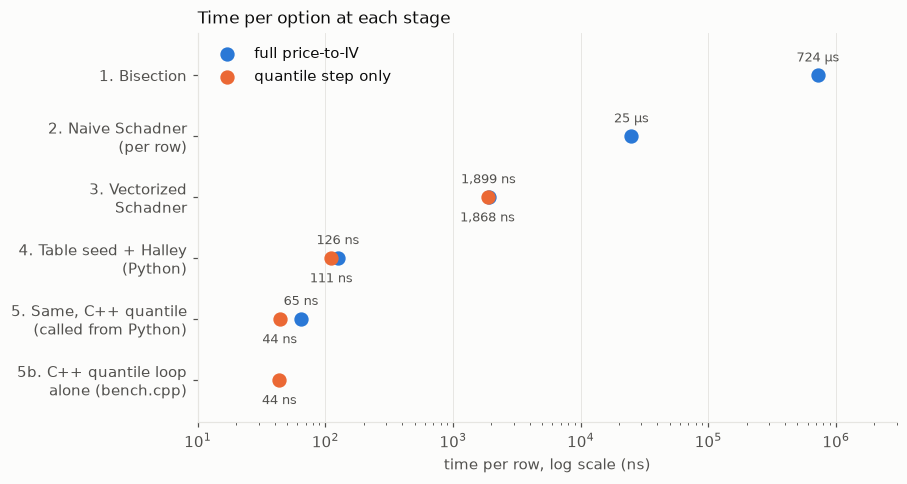

In [5]:
labels = ["1. Bisection", "2. Naive Schadner\n(per row)", "3. Vectorized\nSchadner", "4. Table seed + Halley\n(Python)", "5. Same, C++ quantile\n(called from Python)", "5b. C++ quantile loop\nalone (bench.cpp)"]
y = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
# Where both scopes share a row the dots nearly coincide, so full-pipeline labels go above the
# dot and quantile-step labels below it.
for ys, vals, color, name, dy in ((y, full_ns, BLUE, "full price-to-IV", 9), (y, quant_ns, ORANGE, "quantile step only", -16)):
    ok = ~np.isnan(vals)
    ax.scatter(np.array(vals)[ok], ys[ok], s=70, color=color, zorder=3, label=name)
    for xv, yv in zip(np.array(vals)[ok], ys[ok]):
        ax.annotate(f"{xv:,.0f} ns" if xv < 1e4 else f"{xv/1e3:,.0f} µs", (xv, yv), xytext=(0, dy), textcoords="offset points",
                    ha="center", fontsize=8.5, color=INK2)
ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_ylim(-0.7, len(labels) - 0.3)
ax.set_xlim(10, 3e6)
ax.set_xlabel("time per row, log scale (ns)")
ax.set_title("Time per option at each stage")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left")
plt.show()


## 4. What changed at each step

| Step | Change | Why it is faster | Cost or limit |
|---|---|---|---|
| 1 to 2 | Replace the root-finding loop with Schadner's closed form | One quantile evaluation per row instead of up to 100 Black-Scholes pricings | Needs an inverse-Gaussian quantile, which scipy computes with a generic Boost root-finder |
| 2 to 3 | Call `invgauss.ppf` once on whole arrays | Removes the per-row pandas and Python overhead | The quantile is now about 99% of the runtime |
| 3 to 4 | Seed from a 19 KB table of ln x, then one Halley step in log space | The table gets within 4e-4, and one cubic step finishes. No generic root-finder | Needs a table that matches the data range, and a fallback for rows outside it |
| 4 to 5 | The quantile in C++, called from Python | Removes NumPy's per-pass array overhead in the quantile | Python still does the price mapping, the mask and the square root, and the array copies at the language boundary cost time |

Three design choices carry stage 4, and the first two matter for correctness as much as speed.

- The solver works on the survival side, `s = 1 - p`, and computes `s` directly from the price. On this data `p` is above 0.9 on every row, so `1 - p` would throw away digits.
- It iterates on `y = ln x`, where the survival function is close to a power law or an exponential and Newton-type steps behave well.
- The seed is a 2-D table because `ln x` depends on both `mu` and `s`, and a single scaling variable does not capture it. Polynomial fits needed about 150 terms for 0.2% error.


## 5. Accuracy

The bisection baseline stops when the price error is below 1e-6, so its implied volatility is only as accurate as that price tolerance divided by vega. That makes it a loose yardstick for the three Schadner stages. The table compares each Schadner stage with the naive one-row-at-a-time version, which uses the same formula and the same scipy quantile. It also shows how far each stage is from bisection. Differences are taken over the rows where both stages return a number.


In [6]:
def compare(a, b):
    both = np.isfinite(a) & np.isfinite(b)
    d = np.abs(a - b)[both]
    return both.sum(), np.median(d), d.max(), int((np.isfinite(a) != np.isfinite(b)).sum())

acc_rows = []
for name, iv in (("2. Naive Schadner", iv_naive), ("3. Vectorized Schadner", iv_vec), ("4. Table seed + Halley", iv_table), ("5. C++ quantile", iv_hybrid)):
    _, med_b, max_b, _ = compare(iv, iv_bisect)
    _, _, max_n, _ = compare(iv, iv_naive)
    acc_rows.append({"stage": name, "median |diff| vs bisection": med_b,
                     "max |diff| vs bisection": max_b, "max |diff| vs naive Schadner": max_n})
show(pd.DataFrame(acc_rows).set_index("stage"), {"median |diff| vs bisection": "{:.1e}",
     "max |diff| vs bisection": "{:.1e}", "max |diff| vs naive Schadner": "{:.1e}"})

# Bisection accepts any volatility whose price is within 1e-6 of the target, so its IV can be off by
# up to 1e-6 / vega. Check that bound row by row against the table-seeded result.
both = np.isfinite(iv_table) & np.isfinite(iv_bisect)
sqrt_t = np.sqrt(rows["t"].to_numpy())
d1 = (np.log(rows["spot"].to_numpy() / rows["strike"].to_numpy()) + (rate - dividend + 0.5 * iv_table**2) * rows["t"].to_numpy()) / (iv_table * sqrt_t)
vega = rows["spot"].to_numpy() * np.exp(-dividend * rows["t"].to_numpy()) * norm.pdf(d1) * sqrt_t
ratio = (np.abs(iv_bisect - iv_table) * vega / 1e-6)[both]
display(Markdown(f"Bisection error in units of its own tolerance (|diff| x vega / 1e-6): median {np.median(ratio):.3f}, "
                 f"maximum {ratio.max():.3f}. Bisection stops once the price error is under 1e-6, so values should stay at or below "
                 f"about 1. The vega here is a first-order estimate, so a maximum a little above or below 1 is expected. "
                 f"{N - both.sum():,} of {N:,} rows return NaN in every stage."))


,median |diff| vs bisection,max |diff| vs bisection,max |diff| vs naive Schadner
stage,,,
2. Naive Schadner,1.2e-09,9.4e-06,0.0e+00
3. Vectorized Schadner,1.2e-09,9.4e-06,0.0e+00
4. Table seed + Halley,1.2e-09,9.4e-06,3.1e-12
5. C++ quantile,1.2e-09,9.4e-06,3.1e-12


Bisection error in units of its own tolerance (|diff| x vega / 1e-6): median 0.413, maximum 1.000. Bisection stops once the price error is under 1e-6, so values should stay at or below about 1. The vega here is a first-order estimate, so a maximum a little above or below 1 is expected. 1,249 of 17,966 rows return NaN in every stage.

Naive and vectorized Schadner agree exactly. The table-seeded solver differs from them by at most 3.1e-12 in implied volatility, and the C++ quantile gives the same figure as the Python one. That is most likely scipy's side, because scipy receives `p = 1 - s`, which has already rounded `s`, and the earlier measurements in `quantile_solver/` put that rounding at the same size. All three differ from bisection by a median of 1.2e-9 and at most 9.4e-6. That is expected from bisection's stopping rule, which accepts any volatility whose price is within 1e-6 of the target, and the line above checks the bound row by row. The table-seeded solver is not less accurate than scipy's quantile. Against 50-digit arithmetic its worst relative error on 60 random real rows is about 2.5e-13 in the quantile, which is shown in `quantile_solver/quantile_solver_summary.ipynb`.

Accuracy does degrade in one corner. When the log-moneyness is below about 1e-7, so that `mu` is above about 2e7, the survival function loses precision and the error grows to 1e-9 to 1e-6. More iterations do not help there. The real data stops near `mu` of 7e6, and the cheap remedy is to send those rows to the closed form at the forward.


## 6. Caveats and what is not done

- **C++ scope.** Stage 5 is a hybrid. C++ computes the quantile and Python still does the price mapping, the no-arbitrage mask, the at-the-forward case and the final square root. A pipeline compiled end to end would remove the array copies at the language boundary and the NumPy passes in the mapping. Row 5b, the C++ loop alone, is the floor for what that could reach.
- **Benchmark method.** The C++ timing uses rows sorted by strike and a warm cache, and it includes about 7% clipped quotes at or below intrinsic value that the no-arbitrage mask rejects. Shuffling the rows, reporting the median, and timing valid rows alone would give a number to quote against the paper.
- **Rows outside the table.** The table covers `ln mu` from 0 to 17 and `ln s` from -33 to -2. Rows outside it fall back to an analytic seed and six Newton steps, which is about 20 times slower in C++ because its inverse normal CDF is a simple iteration.
- **Naive timing.** Stages 1 and 2 are timed once, since they take seconds. Stages 3 and 4 are the best of 15 runs, so small differences between them and the loops are not meaningful. The orders of magnitude are.
